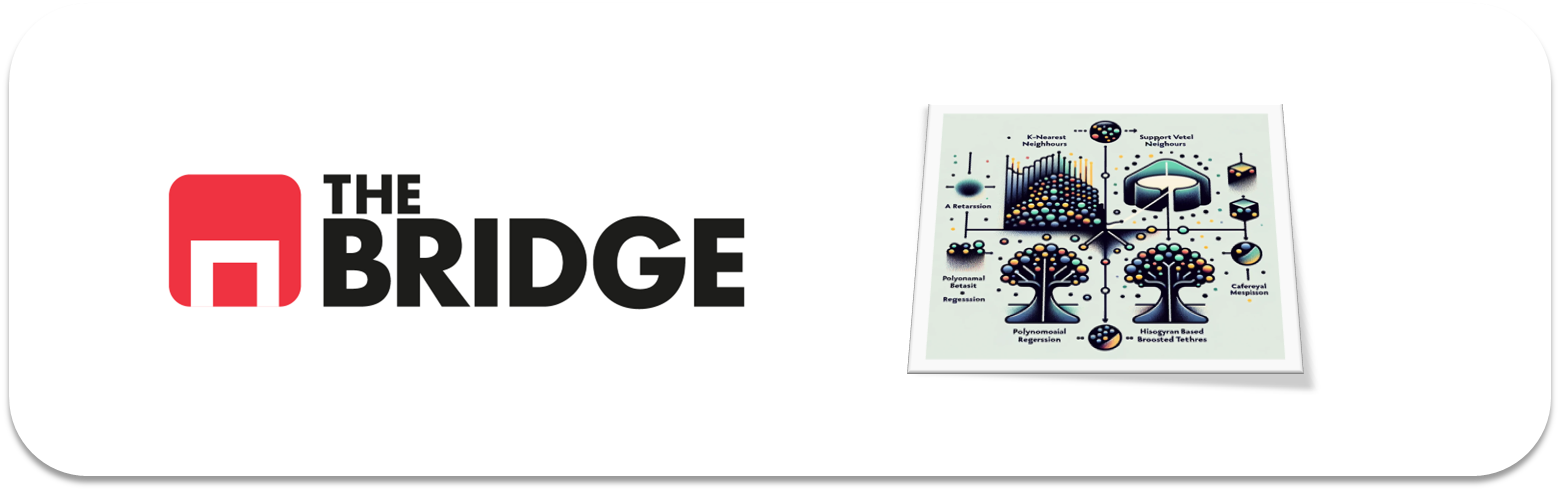

## PRACTICA OBLIGATORIA: **Repaso Aprendizaje Supervisado**

* La práctica obligatoria de esta unidad consiste en resolver sobre un mismo dataset un problema de clasificación y un problema de regresión. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import bootcampviztools as bt

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.utils import resample

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

### #1 Explicación del dataset y carga de datos

Vamos a trabajar con el dataset "Wine Quality", que es un dataset en el que se recogen diversas características fisicoquímicas de las variades tinta y blanca del "Vinho verde" portugués. Las variables del dataset se describen a continuación


1. **Acidez fija**: La mayoría de los ácidos involucrados con el vino son fijos o no volátiles (no se evaporan fácilmente).
2. **Acidez volátil**: La cantidad de ácido acético en el vino, que en niveles demasiado altos puede llevar a un sabor desagradable a vinagre.
3. **Ácido cítrico**: Encontrado en pequeñas cantidades, el ácido cítrico puede añadir 'frescura' y sabor a los vinos.
4. **Azúcar residual**: Es la cantidad de azúcar restante después de que se detiene la fermentación, es raro encontrar vinos con menos de 1 gramo/litro y vinos con más de 45 gramos/litro se consideran dulces.
5. **Cloruros**: La cantidad de sal en el vino.
6. **Dióxido de azufre libre**: La porción libre de SO2 existe en equilibrio entre el SO2 molecular (como un gas disuelto) y el ion bisulfito; previene el crecimiento microbiano y la oxidación del vino.
7. **Dióxido de azufre total**: Es la cantidad de formas libres y ligadas de S02; en bajas concentraciones, el SO2 es en su mayoría indetectable en el vino, pero en concentraciones libres de más de 50 ppm, el SO2 se hace evidente en la nariz y el sabor del vino.
8. **Densidad**: La densidad del vino es cercana a la del agua dependiendo del porcentaje de alcohol y contenido de azúcar.
9. **pH**: Describe qué tan ácido o básico es un vino en una escala de 0 (muy ácido) a 14 (muy básico); la mayoría de los vinos están entre 3-4 en la escala de pH.
10. **Sulfatos**: Un aditivo del vino que puede contribuir a los niveles de dióxido de azufre (SO2), que actúa como un antimicrobiano y antioxidante.
11. **Alcohol**: El porcentaje de contenido de alcohol del vino.
12. **Calidad**: Una variable de salida (basada en datos sensoriales, puntuación entre 0 y 10).
13. **Class**: Si es blanco o tinto.



Carga el dataset "wines_dataset.csv", muestra sus primeras filas, su información general y define dos variables target una para clasificación que permita predecir la calidad del vino según el resto de propiedas y otra variable target para regresión que permita predecir el grado alcohólico del vino a partir del resto de propiedades. 

El **objetivo de negocio en el primer problema** será anticipar la posible clasificación de sus vinos por los catadores profesionales y a partir de ahí poder planificar la producción, distribución y precio a poner a cada vino. En este sentido, el "cliente" nos dice que le gustaría poder clasificar correctamente lo mejor posible en media  (que interpretamos como el mejor recall medio posible).

El **objetivo de negocio en el segundo problema** (bastante artificial) es poder hacer simulaciones de posibles vinos futuros para saber cómo conseguir variedades más o menos alcohólicas para atender mercados diferentes. En este sentido, les interesa equivocarse lo menos posible porcentualmente sobre el grado alochólico real.

Muestra la distribución de ambos targets y haz un pequeño assesment previo de cada problema. NOTA: El dataset está limpio y sin valores faltantes.

In [4]:
df = pd.read_csv("./data/wines_dataset.csv", sep = "|")
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,class
0,8.5,0.21,0.26,9.25,0.034,73.0,142.0,0.99450,3.05,0.37,11.4,6,white
1,8.3,0.16,0.37,7.90,0.025,38.0,107.0,0.99306,2.93,0.37,11.9,6,white
2,6.8,0.18,0.38,1.40,0.038,35.0,111.0,0.99180,3.32,0.59,11.2,7,white
3,6.1,0.26,0.25,2.90,0.047,289.0,440.0,0.99314,3.44,0.64,10.5,3,white
4,7.5,0.63,0.27,2.00,0.083,17.0,91.0,0.99616,3.26,0.58,9.8,6,red
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,7.7,0.39,0.34,10.00,0.056,35.0,178.0,0.99740,3.26,0.60,10.2,5,white
6493,8.2,0.73,0.21,1.70,0.074,5.0,13.0,0.99680,3.20,0.52,9.5,5,red
6494,7.4,0.31,0.48,14.20,0.042,62.0,204.0,0.99830,3.06,0.59,9.4,5,white
6495,8.3,0.65,0.10,2.90,0.089,17.0,40.0,0.99803,3.29,0.55,9.5,5,red


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  class                 6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,6497.0,7.215307,1.296434,3.80000,6.40000,7.00000,7.70000,15.90000
volatile acidity,6497.0,0.339666,0.164636,0.08000,0.23000,0.29000,0.40000,1.58000
citric acid,6497.0,0.318633,0.145318,0.00000,0.25000,0.31000,0.39000,1.66000
residual sugar,6497.0,5.443235,4.757804,0.60000,1.80000,3.00000,8.10000,65.80000
chlorides,6497.0,0.056034,0.035034,0.00900,0.03800,0.04700,0.06500,0.61100
free sulfur dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000
total sulfur dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6497.0,3.218501,0.160787,2.72000,3.11000,3.21000,3.32000,4.01000
sulphates,6497.0,0.531268,0.148806,0.22000,0.43000,0.51000,0.60000,2.00000


In [8]:
df.nunique()

fixed acidity           106
volatile acidity        187
citric acid              89
residual sugar          316
chlorides               214
free sulfur dioxide     135
total sulfur dioxide    276
density                 998
pH                      108
sulphates               111
alcohol                 111
quality                   7
class                     2
dtype: int64

In [9]:
df["quality"].unique()

array([6, 7, 3, 5, 4, 8, 9])

### #2 Modelado para clasificación

Crea un modelo que permita clasificar lo mejor posible los vinos en función de su calidad, o dicho de otro modo que prediga de la mejor manera posible la calidad de un vino a partir de sus propiedades químicas. ***Considéralo un problema de clasificación***, donde los valores de calidad son las clases a predecir. Puedes utilizar los modelos que creas conveniente, al menos tres, y utiliza un KNN como modelo baseline, prueba al menos con 2 valores de K. Intenta mejorar el "recall medio" con las técnicas que creas conveniente. Compara los modelos utilizando validación cruzada con o sin optimización previa de hiperparámetros (aunque en la sesión en vivo por limitación de tiempos sólo lo haremos con validación cruzada). El modelo elegido si tiene que tener un ejemplo de optimización de parámetros.

Evalúa el modelo, analiza los errores y propón algún mecanismo de mejora aunque sea sólo un esbozo.

### Clasificacíon

In [7]:
target = "quality"

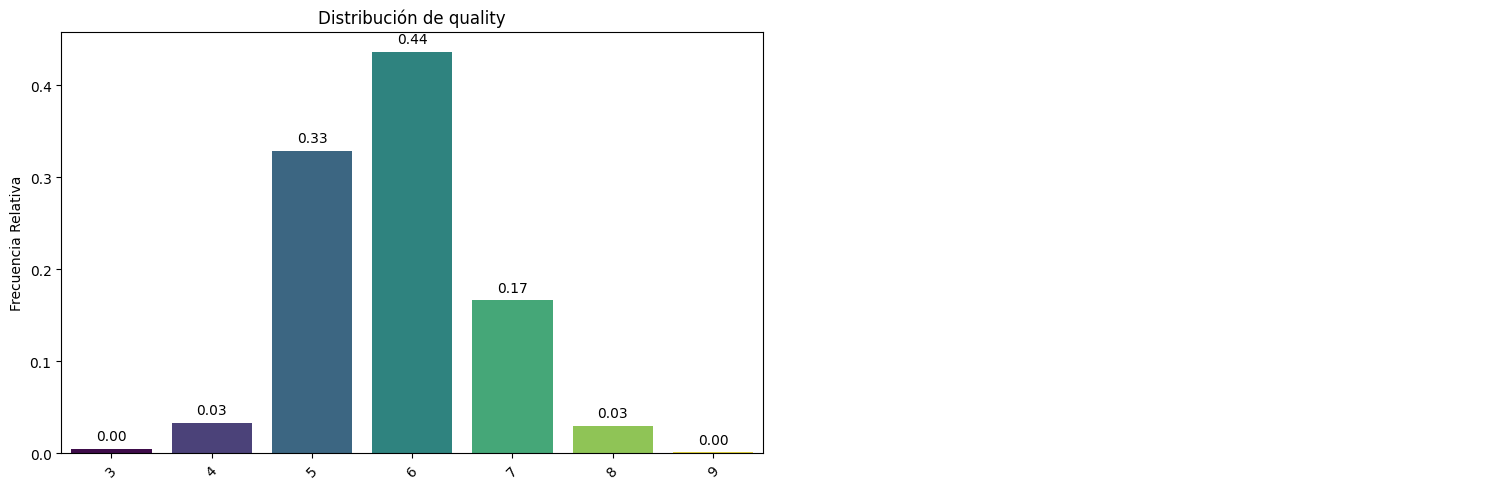

In [10]:
bt.pinta_distribucion_categoricas(df, [target], mostrar_valores= True, relativa= True)

In [11]:
# me voy a crear un target binatio donde sea buena calidad y mala calidad

df_qbinario = df.copy()
df_qbinario["quality_bin"] = (df_qbinario["quality"] >= 7).astype(int)

target = "quality_bin"

In [12]:
features_cat = ["class"]

features_num = df_qbinario.columns.drop(["quality", target] + features_cat).tolist()

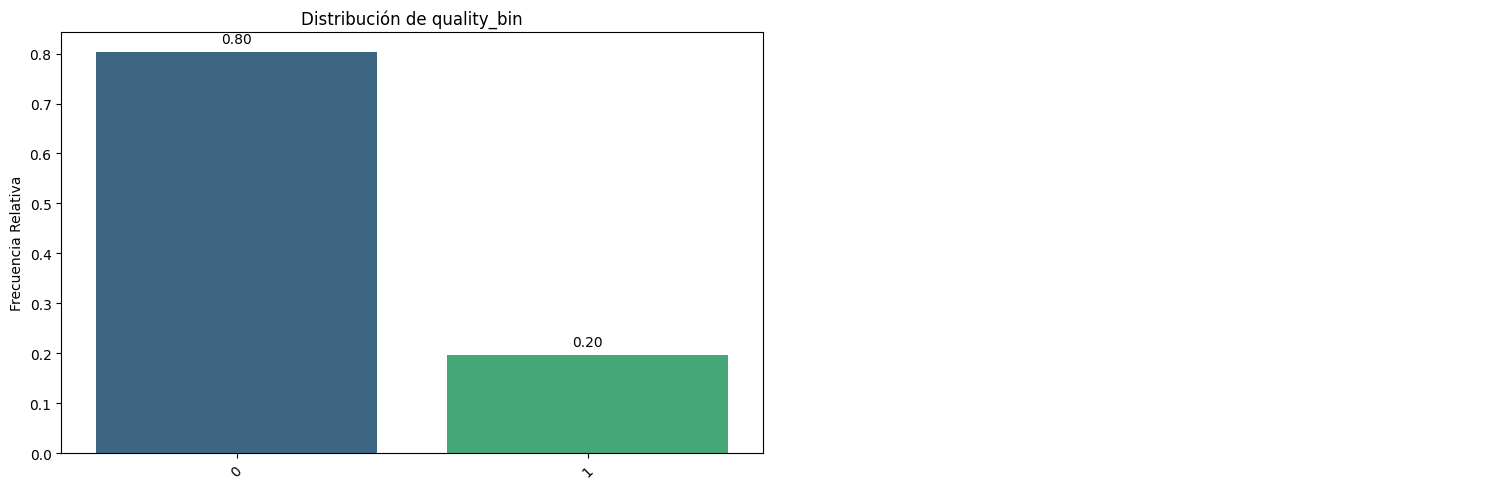

In [ ]:
# Ahora que "binaricé" mi target, lo vuelvo a revisar para ver su balanceo y está un 80-20

bt.pinta_distribucion_categoricas(df_qbinario, [target], mostrar_valores= True, relativa= True)

In [15]:
train_set, test_set = train_test_split(df_qbinario, test_size= 0.2, random_state= 42, stratify= df_qbinario["quality_bin"])

In [16]:
print(train_set["quality_bin"].value_counts(normalize=True))
print(test_set["quality_bin"].value_counts(normalize=True))

quality_bin
0    0.803541
1    0.196459
Name: proportion, dtype: float64
quality_bin
0    0.803077
1    0.196923
Name: proportion, dtype: float64


In [17]:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5197 entries, 4103 to 3985
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         5197 non-null   float64
 1   volatile acidity      5197 non-null   float64
 2   citric acid           5197 non-null   float64
 3   residual sugar        5197 non-null   float64
 4   chlorides             5197 non-null   float64
 5   free sulfur dioxide   5197 non-null   float64
 6   total sulfur dioxide  5197 non-null   float64
 7   density               5197 non-null   float64
 8   pH                    5197 non-null   float64
 9   sulphates             5197 non-null   float64
 10  alcohol               5197 non-null   float64
 11  quality               5197 non-null   int64  
 12  class                 5197 non-null   object 
 13  quality_bin           5197 non-null   int64  
dtypes: float64(11), int64(2), object(1)
memory usage: 609.0+ KB


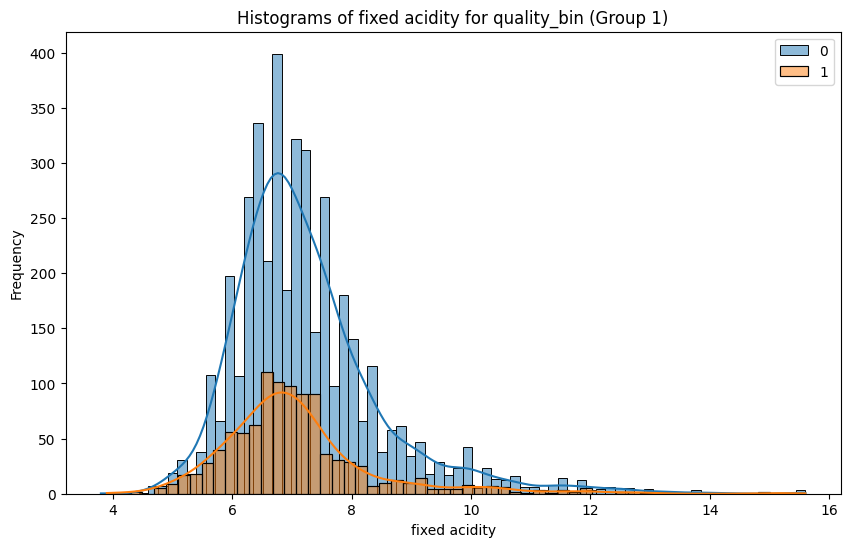

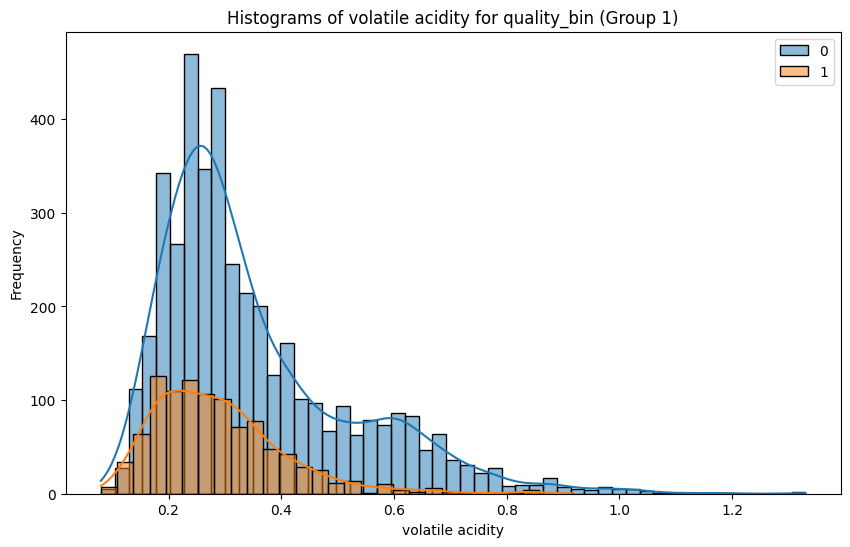

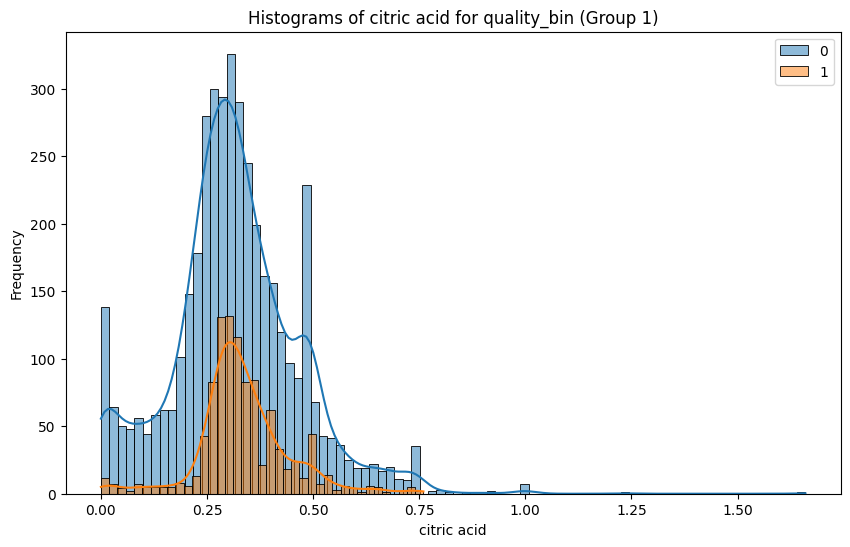

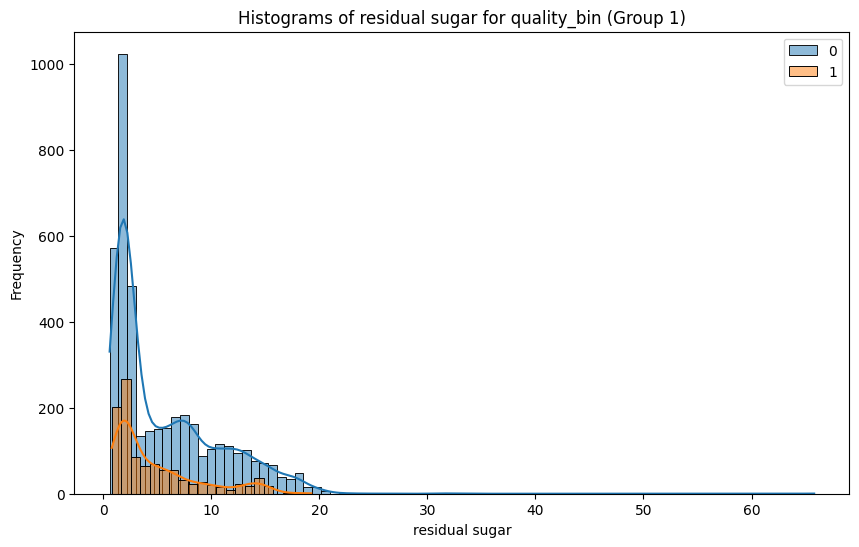

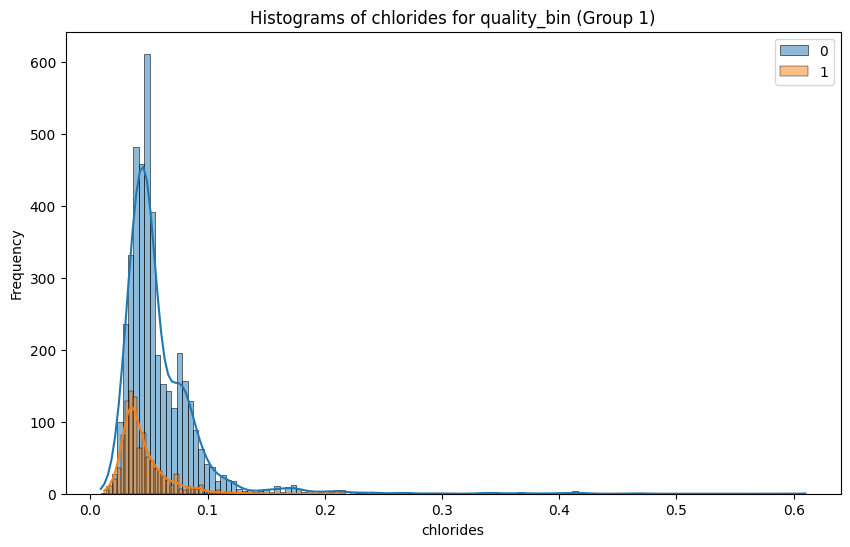

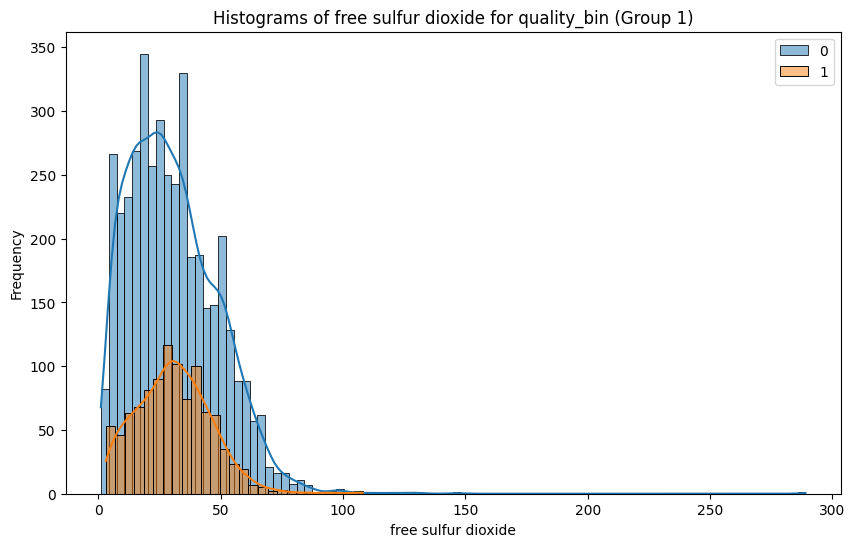

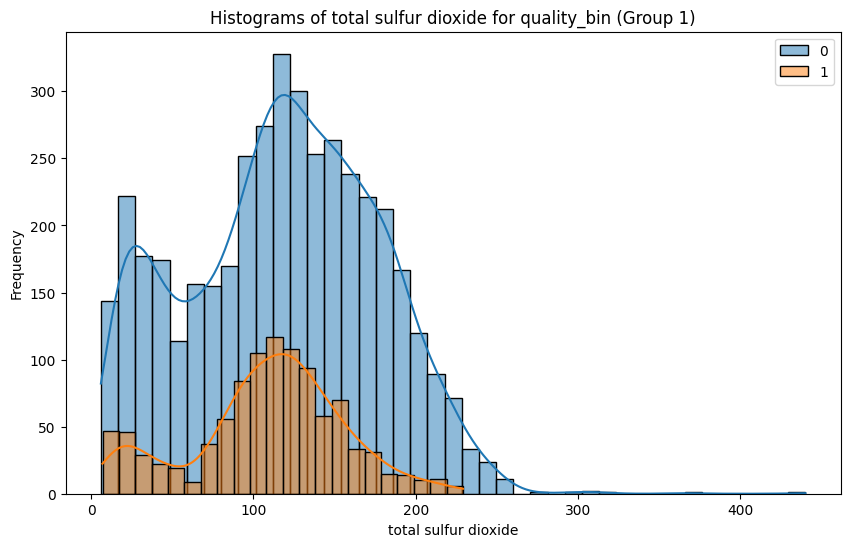

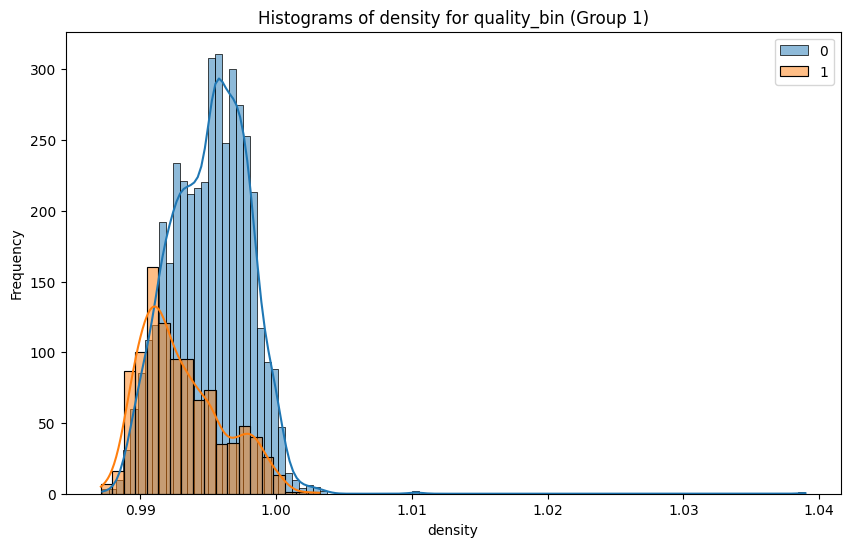

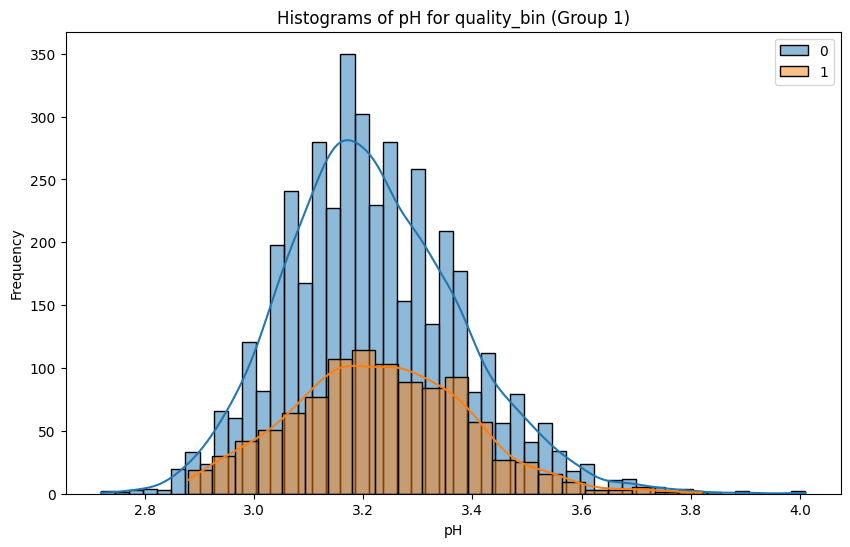

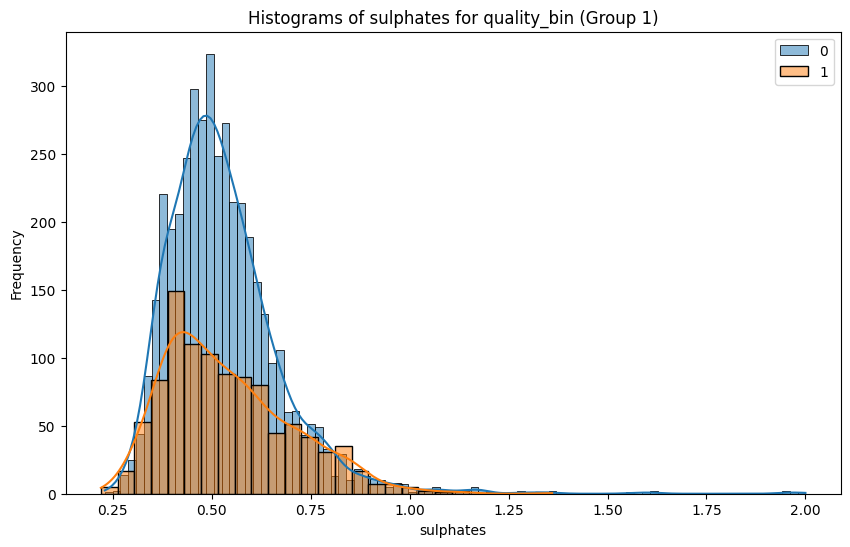

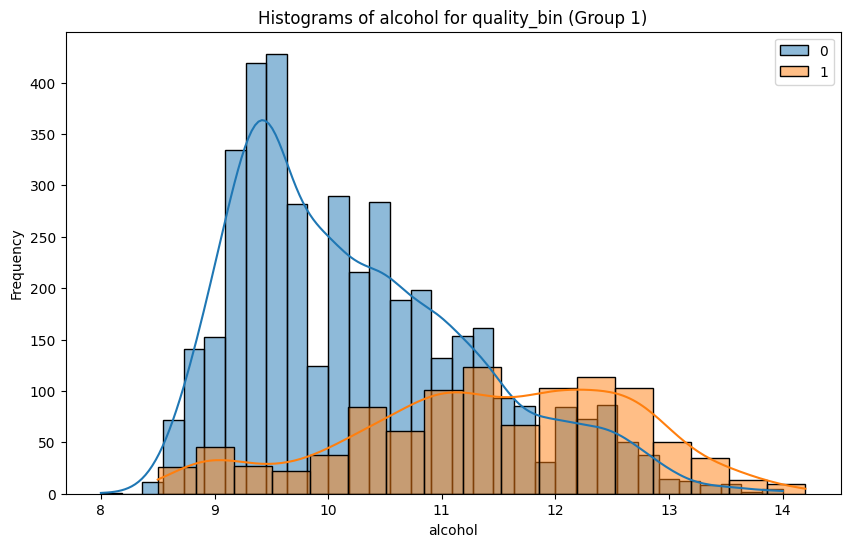

In [18]:
for col in features_num:
    bt.plot_grouped_histograms(train_set, cat_col=target, num_col=col, group_size=2)

"alcohol" muestra una separación visible entre clases: los vinos con quality_bin=1 tienden a concentrarse en valores de alcohol más altos. Puede ser una variable predictiva relevante.

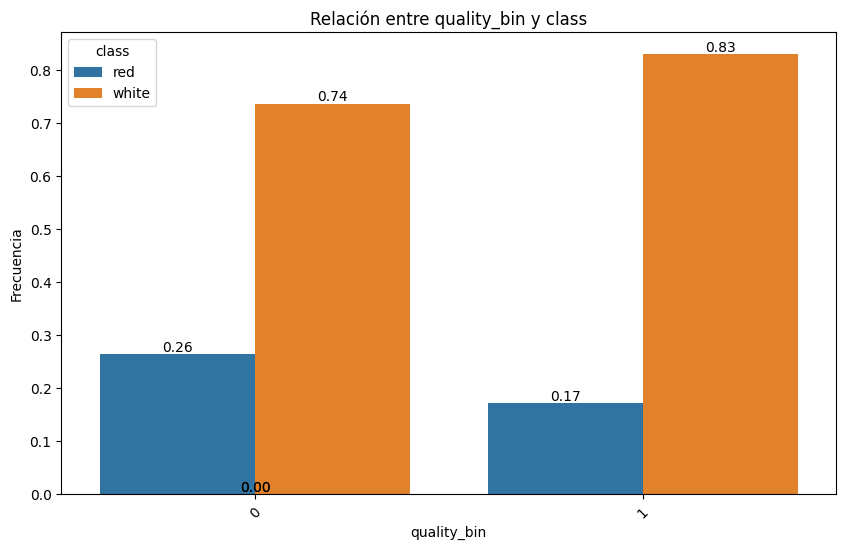

In [19]:
bt.plot_categorical_relationship_fin(train_set, target, "class", show_values= True, relative_freq= True)

In [20]:
train_set.groupby("class")[target].mean()

class
red      0.136933
white    0.215871
Name: quality_bin, dtype: float64

Relación class (red/white) vs quality_bin:

Proporción de “buena calidad” (quality_bin=1) por tipo:

red: 0.137 (13.7%)
white: 0.216 (21.6%)

Los vinos blancos tienen mayor probabilidad de caer en la clase “buena calidad” que los tintos, por lo que class aporta señal predictiva.

In [22]:
X_train = train_set[features_num + features_cat]
y_train = train_set[target]
X_test  = test_set[features_num + features_cat]
y_test  = test_set[target]

In [23]:
print("Train class unique:", train_set["class"].unique())
print("Test  class unique:", test_set["class"].unique())

print("Train counts:\n", train_set["class"].value_counts())
print("Test  counts:\n", test_set["class"].value_counts())

Train class unique: ['red' 'white']
Test  class unique: ['white' 'red']
Train counts:
 class
white    3919
red      1278
Name: count, dtype: int64
Test  counts:
 class
white    979
red      321
Name: count, dtype: int64


#### Preprocesado

In [24]:
X_train = pd.get_dummies(X_train, columns=["class"], drop_first=True)
X_test  = pd.get_dummies(X_test,  columns=["class"], drop_first=True)

scaler = StandardScaler()

X_train[features_num] = scaler.fit_transform(X_train[features_num])
X_test[features_num]  = scaler.transform(X_test[features_num])

In [27]:
knn_5 = KNeighborsClassifier(n_neighbors=5)

scores_cv = cross_val_score(knn_5, X_train, y_train, cv=5, scoring="recall")

print("Recall medio (CV=5):", scores_cv.mean())
print("Recalls por fold:", scores_cv)

Recall medio (CV=5): 0.49467718794835014
Recalls por fold: [0.44117647 0.42926829 0.54901961 0.55392157 0.5       ]


KNN (k=5) — TEST
              precision    recall  f1-score   support

           0       0.88      0.93      0.91      1044
           1       0.63      0.50      0.56       256

    accuracy                           0.84      1300
   macro avg       0.76      0.71      0.73      1300
weighted avg       0.83      0.84      0.84      1300



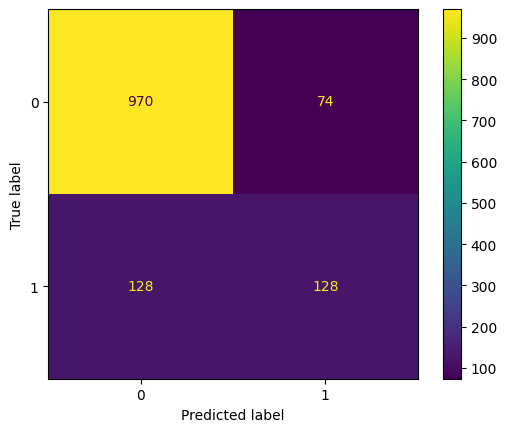

In [28]:
knn_5.fit(X_train, y_train)
pred_test = knn_5.predict(X_test)

print("KNN (k=5) — TEST")
print(classification_report(y_test, pred_test))

ConfusionMatrixDisplay.from_predictions(y_test, pred_test)

plt.show()

KNN (k=5), Evaluación (TEST):  

El modelo identifica muy bien los vinos de baja calidad (recall clase 0 ≈ 0.93), pero tiene un rendimiento moderado detectando vinos de buena calidad (recall clase 1 = 0.50).  

En la matriz de confusión se observa un número relevante de falsos negativos (buenos clasificados como malos: 128), lo que reduce el recall de la clase positiva (vino bueno).

KNN (k=15), Recall medio (CV=5): 0.41341463414634144
Recalls por fold: [0.3872549  0.31707317 0.49509804 0.45098039 0.41666667]

KNN (k=15), TEST
              precision    recall  f1-score   support

           0       0.87      0.94      0.90      1044
           1       0.63      0.43      0.51       256

    accuracy                           0.84      1300
   macro avg       0.75      0.68      0.71      1300
weighted avg       0.82      0.84      0.83      1300



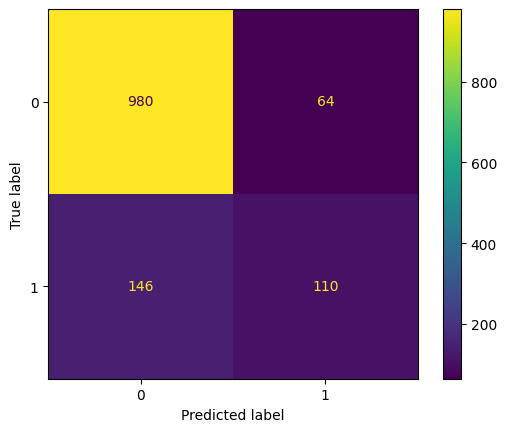

In [30]:
k = 15

knn_15 = KNeighborsClassifier(n_neighbors=k)

scores_cv_15 = cross_val_score(knn_15, X_train, y_train, cv=5, scoring="recall")

print(f"KNN (k={k}), Recall medio (CV=5):", scores_cv_15.mean())
print("Recalls por fold:", scores_cv_15)

knn_15.fit(X_train, y_train)
pred_test_15 = knn_15.predict(X_test)

print(f"\nKNN (k={k}), TEST")
print(classification_report(y_test, pred_test_15))

ConfusionMatrixDisplay.from_predictions(y_test, pred_test_15)
plt.show()

KNN: al aumentar k de 5 a 15, el modelo se vuelve más conservador. Mejora el recall de vinos malos (clase 0) pero empeora la detección de vinos buenos (clase 1).
Si el objetivo del negocio es captar/identificar vinos buenos, k=5 es preferible a k=15 en recall de clase 1, aunque el rendimiento sigue siendo limitado.

In [31]:
randomf_base = RandomForestClassifier(random_state=42,
                                      n_estimators=200)

scores_cv_randomf = cross_val_score(randomf_base, X_train, y_train,
                                    cv=5,
                                    scoring="recall")

print("Random Forest, Recall medio (CV=5):", np.mean(scores_cv_randomf))
print("Recalls por fold:", scores_cv_randomf)

Random Forest, Recall medio (CV=5): 0.5387135341941655
Recalls por fold: [0.4754902  0.51219512 0.59803922 0.58333333 0.5245098 ]


Random Forest TEST
              precision    recall  f1-score   support

           0       0.90      0.97      0.93      1044
           1       0.81      0.58      0.68       256

    accuracy                           0.89      1300
   macro avg       0.85      0.77      0.80      1300
weighted avg       0.88      0.89      0.88      1300



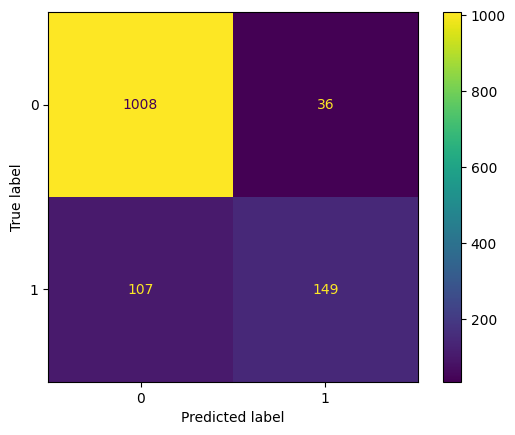

In [32]:
randomf_base.fit(X_train, y_train)
pred_test_randomf = randomf_base.predict(X_test)

print("Random Forest TEST")
print(classification_report(y_test, pred_test_randomf))

ConfusionMatrixDisplay.from_predictions(y_test, pred_test_randomf)

plt.show()

### #3 Modelado para regresión

Reutiliza todo lo que puedas la preparación del modelado de la parte anterior y construye ahora el mejor modelo que puedas para predecir el grado alcohólico de un vino dadas sus características fisico químicas, su clase y la puntuación de calidad que le ha sido otorgada. Compara al menos tres tipos de modelos, seleccionando una métrica adecuada de comparación y escoge el más apropiado empleando validación cruzada antes o después de optimizar hiperparámetros (en la sesión en vivo lo haremos antes por cuestiones de tiempo). Evalúa el modelo escogido y con los hiperparámetros ajustados de la mejor manera que puedas. Para terminar realizar un pequeño análisis de errores.

In [ ]:
import sys
print(sys.executable)